In [83]:
# Basic Polynomial Regression Example

import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


In [84]:
import seaborn as sns

In [85]:

# Load dataset
df = pd.read_csv("real_estate_polynomial_data.csv")
df.head()

,Distance_km,House_Price_Thousands
0,1.000000,772.384283
1,1.292929,749.588640
2,1.585859,755.607378
3,1.878788,763.802100
4,2.171717,719.727005


In [86]:

# Feature and target
X = df[["Distance_km"]]
y = df["House_Price_Thousands"]


In [87]:

# Transform to polynomial features (degree = 2)
poly = PolynomialFeatures(degree=6, include_bias=False)

poly

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",6
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [88]:
X_poly = poly.fit_transform(X)
X_poly

array([[1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00],
       [1.29292929e+00, 1.67166616e+00, 2.16134614e+00, 2.79446774e+00,
        3.61304920e+00, 4.67141715e+00],
       [1.58585859e+00, 2.51494745e+00, 3.98835101e+00, 6.32496070e+00,
        1.00304932e+01, 1.59069438e+01],
       [1.87878788e+00, 3.52984389e+00, 6.63182792e+00, 1.24597979e+01,
        2.34093173e+01, 4.39811416e+01],
       [2.17171717e+00, 4.71635548e+00, 1.02425902e+01, 2.22440090e+01,
        4.83076963e+01, 1.04910653e+02],
       [2.46464646e+00, 6.07448220e+00, 1.49714511e+01, 3.68993340e+01,
        9.09438130e+01, 2.24144347e+02],
       [2.75757576e+00, 7.60422406e+00, 2.09692239e+01, 5.78242236e+01,
        1.59454677e+02, 4.39708352e+02],
       [3.05050505e+00, 9.30558107e+00, 2.83867220e+01, 8.65938390e+01,
        2.64154943e+02, 8.05805988e+02],
       [3.34343434e+00, 1.11785532e+01, 3.73747587e+01, 1.24960052e+02,
        4.17795729e+02, 

In [89]:

# Train model
model = LinearRegression()
model.fit(X_poly, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [90]:

# Model coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: 829.2145521650508
Coefficients: [-5.53790883e+01  4.87812296e+00 -2.37245067e-01  8.55203840e-03
 -2.12775373e-04  2.17868510e-06]


In [91]:

# Prediction example
# sample_distance = [[15]]
sample_distance = X
sample_poly = poly.transform(sample_distance)

sample_poly

array([[1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 1.00000000e+00],
       [1.29292929e+00, 1.67166616e+00, 2.16134614e+00, 2.79446774e+00,
        3.61304920e+00, 4.67141715e+00],
       [1.58585859e+00, 2.51494745e+00, 3.98835101e+00, 6.32496070e+00,
        1.00304932e+01, 1.59069438e+01],
       [1.87878788e+00, 3.52984389e+00, 6.63182792e+00, 1.24597979e+01,
        2.34093173e+01, 4.39811416e+01],
       [2.17171717e+00, 4.71635548e+00, 1.02425902e+01, 2.22440090e+01,
        4.83076963e+01, 1.04910653e+02],
       [2.46464646e+00, 6.07448220e+00, 1.49714511e+01, 3.68993340e+01,
        9.09438130e+01, 2.24144347e+02],
       [2.75757576e+00, 7.60422406e+00, 2.09692239e+01, 5.78242236e+01,
        1.59454677e+02, 4.39708352e+02],
       [3.05050505e+00, 9.30558107e+00, 2.83867220e+01, 8.65938390e+01,
        2.64154943e+02, 8.05805988e+02],
       [3.34343434e+00, 1.11785532e+01, 3.73747587e+01, 1.24960052e+02,
        4.17795729e+02, 

<Axes: >

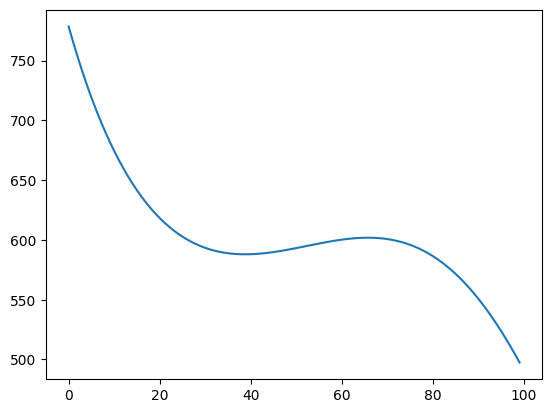

In [92]:
prediction = model.predict(sample_poly)
sns.lineplot(prediction)

In [93]:

print("Predicted price (in thousands):", prediction[0])

Predicted price (in thousands): 778.4846831696234


<Axes: xlabel='Distance_km', ylabel='House_Price_Thousands'>

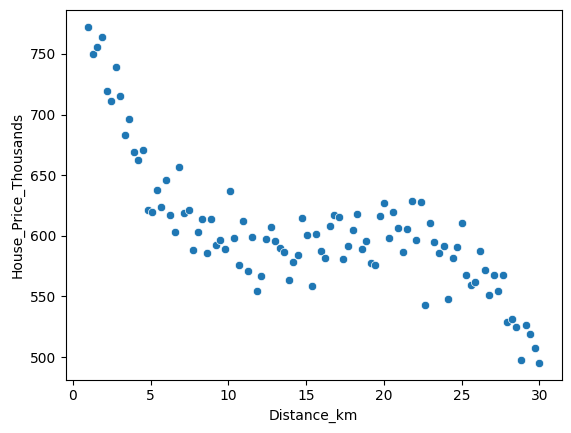

In [94]:
sns.scatterplot(df, x="Distance_km", y="House_Price_Thousands")